# Exploratory Data Analysis
---


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append('../scripts')
from data_utils import path, column_order, labels

In [2]:
# Load data
data_entry_df = pd.read_pickle('../data/interim/data_entry_df.pkl')
train_val_list = pd.read_pickle('../data/interim/train_val_list.pkl')
test_list = pd.read_pickle('../data/interim/test_list.pkl')
patient_data = pd.read_pickle('../data/interim/patient_data.pkl')

In [3]:
# Show unique classes
labels_exploded = data_entry_df["finding_labels"].str.split('|').explode()
sorted(labels_exploded.unique())

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Effusion',
 'Emphysema',
 'Fibrosis',
 'Hernia',
 'Infiltration',
 'Mass',
 'No Finding',
 'Nodule',
 'Pleural_Thickening',
 'Pneumonia',
 'Pneumothorax']

In [4]:
# Inner joined data between data_entry_df and both test and training datasets
# Created a new filtered dataset where it includes data from both datasets only where 'image_index' matches both datasets

filtered_test_list = data_entry_df.merge(test_list, on='image_index', how='inner')
filtered_train_val_list = data_entry_df.merge(train_val_list, on='image_index', how='inner')

display(filtered_test_list.head())
display(filtered_train_val_list.head())

,image_index,finding_labels,follow_up_number,patient_id,patient_age,patient_gender,view_position,original_img_width,original_img_height,img_pixel_spacing_x,img_pixel_spacing_y
0,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143
1,00000003_001.png,Hernia,1,3,74,F,PA,2500,2048,0.168,0.168
2,00000003_002.png,Hernia,2,3,75,F,PA,2048,2500,0.168,0.168
3,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143
4,00000003_004.png,Hernia,4,3,77,F,PA,2500,2048,0.168,0.168


,image_index,finding_labels,follow_up_number,patient_id,patient_age,patient_gender,view_position,original_img_width,original_img_height,img_pixel_spacing_x,img_pixel_spacing_y
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171
4,00000004_000.png,Mass|Nodule,0,4,82,M,AP,2500,2048,0.168,0.168


## Split and encode target variable

In [5]:
# encode target variable classes (train_val_list)
train_X = filtered_train_val_list.drop("finding_labels", axis=1)
train_y = filtered_train_val_list["finding_labels"]

# y = target variable
# X = features

def create_labels(X, y):
    mlb = MultiLabelBinarizer()

    y_split = y.str.split('|')
    y_encoded = mlb.fit_transform(y_split)
    classes = mlb.classes_

    encoded_df = pd.DataFrame(columns=classes, data=y_encoded)
    labeled_df = X.join(encoded_df,how="inner").drop(columns=['original_img_height', 'img_pixel_spacing_x', 'img_pixel_spacing_y'], axis=1)
    labeled_df = labeled_df.reindex(columns=column_order)
    labeled_df[labels] = labeled_df[labels].fillna(0).astype(int) #fill missing data with 0

    return labeled_df


train_val_labels = create_labels(train_X, train_y)
train_val_labels.head()

,image_index,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,follow_up_number,patient_id,patient_age,patient_gender,view_position
0,00000001_000.png,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,58,M,PA
1,00000001_001.png,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,1,1,58,M,PA
2,00000001_002.png,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,2,1,58,M,PA
3,00000002_000.png,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,2,81,M,PA
4,00000004_000.png,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,4,82,M,AP


In [6]:
# encode target variable classes (test_list)
test_X = filtered_test_list.drop("finding_labels", axis=1)
test_y = filtered_test_list["finding_labels"]

test_labels = create_labels(test_X,test_y)
test_labels.head()

,image_index,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,...,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,follow_up_number,patient_id,patient_age,patient_gender,view_position
0,00000003_000.png,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,3,81,F,PA
1,00000003_001.png,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,3,74,F,PA
2,00000003_002.png,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,2,3,75,F,PA
3,00000003_003.png,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,3,3,76,F,PA
4,00000003_004.png,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,4,3,77,F,PA


In [7]:
# split into X and y for statistical analysis 

train_labels_y = train_val_labels.drop(columns=["image_index", "follow_up_number", "patient_age", "patient_id", "patient_gender", "view_position"])
train_labels_X = train_val_labels.drop(columns=labels+["image_index", "patient_id"])

## Outlier Detection 

In [8]:
# Summary statistics on training features
train_labels_X.describe()

,follow_up_number,patient_age
count,86523.000000,86523.000000
mean,5.096668,46.870162
std,8.656979,16.835510
min,0.000000,1.000000
25%,0.000000,35.000000
50%,2.000000,49.000000
75%,6.000000,59.000000
max,108.000000,413.000000


Based on the summary statistics, there are clear outliers in the follow_up_number and patient_age columns. The oldest patient being 413 years old a clear outlier in the data while the jump from 6 follow-ups at the 75th percentile to over 100 at the 100th percentile is significant enough to signal an outlier

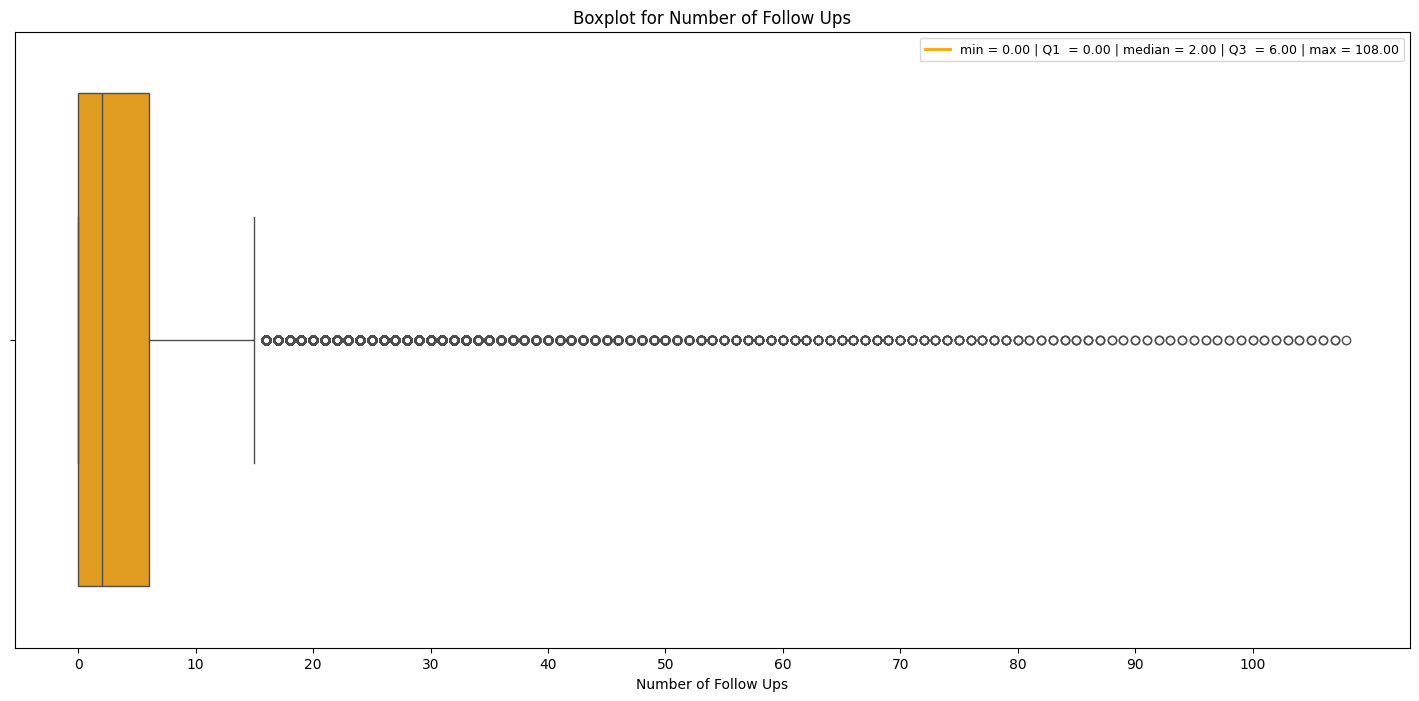

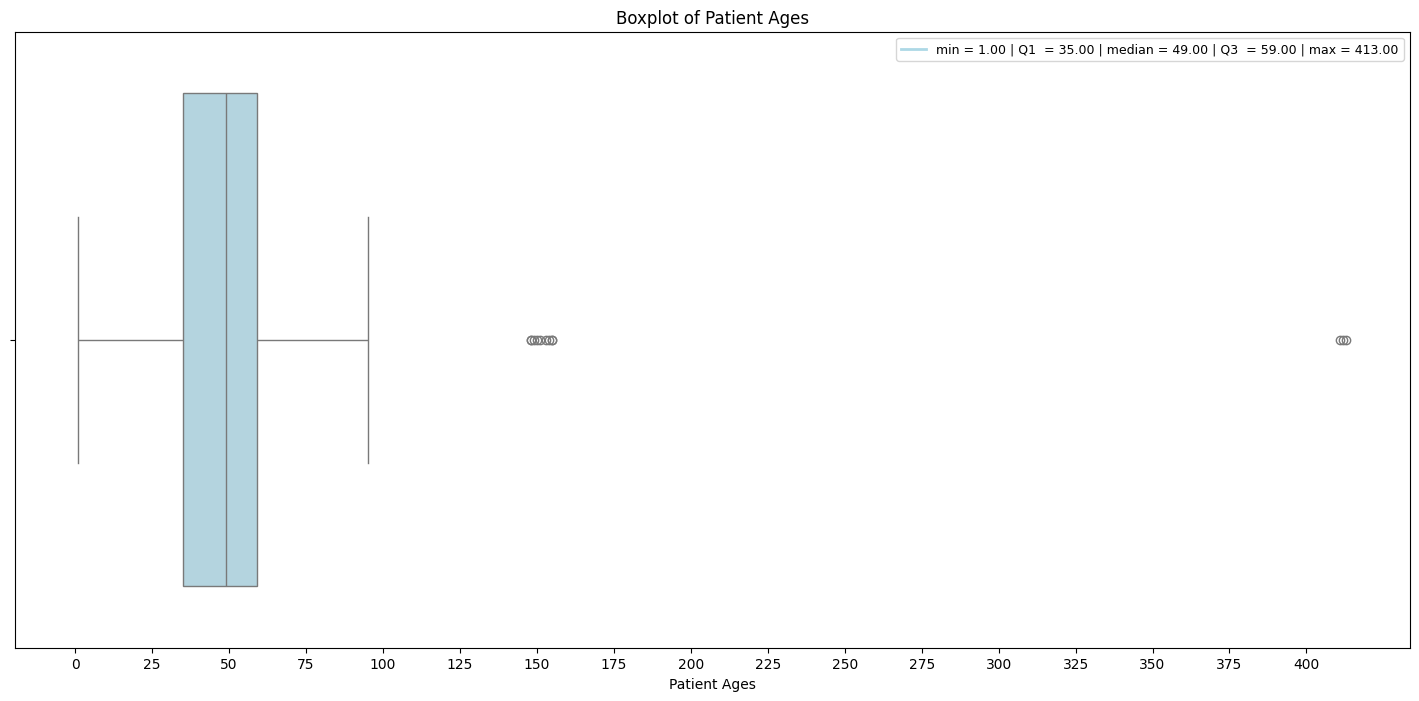

In [9]:
# Boxplot highlighting outliers (follow_up_number and patient_age)

# Follow up number boxplot
follow_desc = train_labels_X["follow_up_number"].describe()

plt.figure(figsize=(18,8))
ax = sns.boxplot(train_labels_X["follow_up_number"], orient="h", color="orange")
plt.title("Boxplot for Number of Follow Ups")
plt.xticks(range(0,train_labels_X["follow_up_number"].max(), 10))
plt.xlabel("Number of Follow Ups")

stats_text = [
    f"min = {follow_desc['min']:.2f}",
    f"Q1  = {follow_desc['25%']:.2f}",
    f"median = {follow_desc['50%']:.2f}",
    f"Q3  = {follow_desc['75%']:.2f}",
    f"max = {follow_desc['max']:.2f}"
]

ax.legend([plt.Line2D([0], [0], color="orange", lw=2)], [" | ".join(stats_text)], loc="upper right", fontsize=9)
plt.show()


# Patient age boxplot
age_desc = train_labels_X["patient_age"].describe()

plt.figure(figsize=(18,8))
ax = sns.boxplot(train_labels_X["patient_age"], orient="h", color="lightblue")
plt.title("Boxplot of Patient Ages")
plt.xticks(range(0,train_labels_X["patient_age"].max(), 25))
plt.xlabel("Patient Ages")

stats_text = [
    f"min = {age_desc['min']:.2f}",
    f"Q1  = {age_desc['25%']:.2f}",
    f"median = {age_desc['50%']:.2f}",
    f"Q3  = {age_desc['75%']:.2f}",
    f"max = {age_desc['max']:.2f}"
]

ax.legend([plt.Line2D([0], [0], color="lightblue", lw=2)], [" | ".join(stats_text)], loc="upper right", fontsize=9)
plt.show()

In [10]:
# Calculate IQR and identify upper and lower outlier thresholds

# Follow up number
f_IQR = follow_desc["75%"] - follow_desc["25%"]
f_max_threshold = follow_desc["75%"] + (1.5 * f_IQR)
f_min_threshold = (follow_desc["25%"] - (1.5 * f_IQR))
print(f"Follow_up_number: \n Upper Threshold = {f_max_threshold} \n Lower Threshold = {f_min_threshold}")

# Patient age
age_IQR = age_desc["75%"] - age_desc["25%"]
age_max_threshold = age_desc["75%"] + (1.5 * age_IQR)
age_min_threshold = (age_desc["25%"] - (1.5 * f_IQR))
print(f"Patient_age: \n Upper Threshold = {age_max_threshold} \n Lower Threshold = {age_min_threshold}")

# Remove outliers from dataset

train_val_labels = train_val_labels[(train_labels_X["follow_up_number"] >= f_min_threshold) & 
                              (train_labels_X["follow_up_number"] <= f_max_threshold) & 
                              (train_labels_X["patient_age"] >= age_min_threshold) & 
                              (train_labels_X["patient_age"] <= age_max_threshold)]

# Apply split for analysis again after outlier removal
train_labels_y = train_val_labels.drop(columns=["image_index", "follow_up_number", "patient_age", "patient_id", "patient_gender", "view_position"])
train_labels_X = train_val_labels.drop(columns=labels+["image_index", "patient_id"])

Follow_up_number: 
 Upper Threshold = 15.0 
 Lower Threshold = -9.0
Patient_age: 
 Upper Threshold = 95.0 
 Lower Threshold = 26.0


## Descriptive Statistical Analysis

In [11]:
# reset index  
flat_df = patient_data.reset_index()
flat_df.head()

,patient_id,follow_up_number,image_index,finding_labels,patient_age,patient_gender,view_position
0,1,0,00000001_000.png,Cardiomegaly,58,M,PA
1,1,1,00000001_001.png,Cardiomegaly|Emphysema,58,M,PA
2,1,2,00000001_002.png,Cardiomegaly|Effusion,58,M,PA
3,2,0,00000002_000.png,No Finding,81,M,PA
4,3,0,00000003_000.png,Hernia,81,F,PA


In [12]:
# total number of unique patients
data_entry_df["patient_id"].nunique()

30805

In [13]:
# checking dataset dimensions
print(f'Patient data shape: {flat_df.shape}')
print(f'Data entry shape: {data_entry_df.shape}')

Patient data shape: (112120, 7)
Data entry shape: (112120, 11)


In [14]:
# cheking data types
flat_df.info()
data_entry_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   patient_id        112120 non-null  int64 
 1   follow_up_number  112120 non-null  int64 
 2   image_index       112120 non-null  object
 3   finding_labels    112120 non-null  object
 4   patient_age       112120 non-null  int64 
 5   patient_gender    112120 non-null  object
 6   view_position     112120 non-null  object
dtypes: int64(3), object(4)
memory usage: 6.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   image_index          112120 non-null  object 
 1   finding_labels       112120 non-null  object 
 2   follow_up_number     112120 non-null  int64  
 3   patient_id           112120 non-null  int64  


follow_up_number
0     1.108376
1     1.158849
2     1.212527
3     1.244729
4     1.269853
5     1.283073
6     1.285512
7     1.311510
8     1.322895
9     1.310976
10    1.297903
11    1.293207
12    1.360887
13    1.320733
14    1.350543
15    1.351145
Name: disease_count, dtype: float64


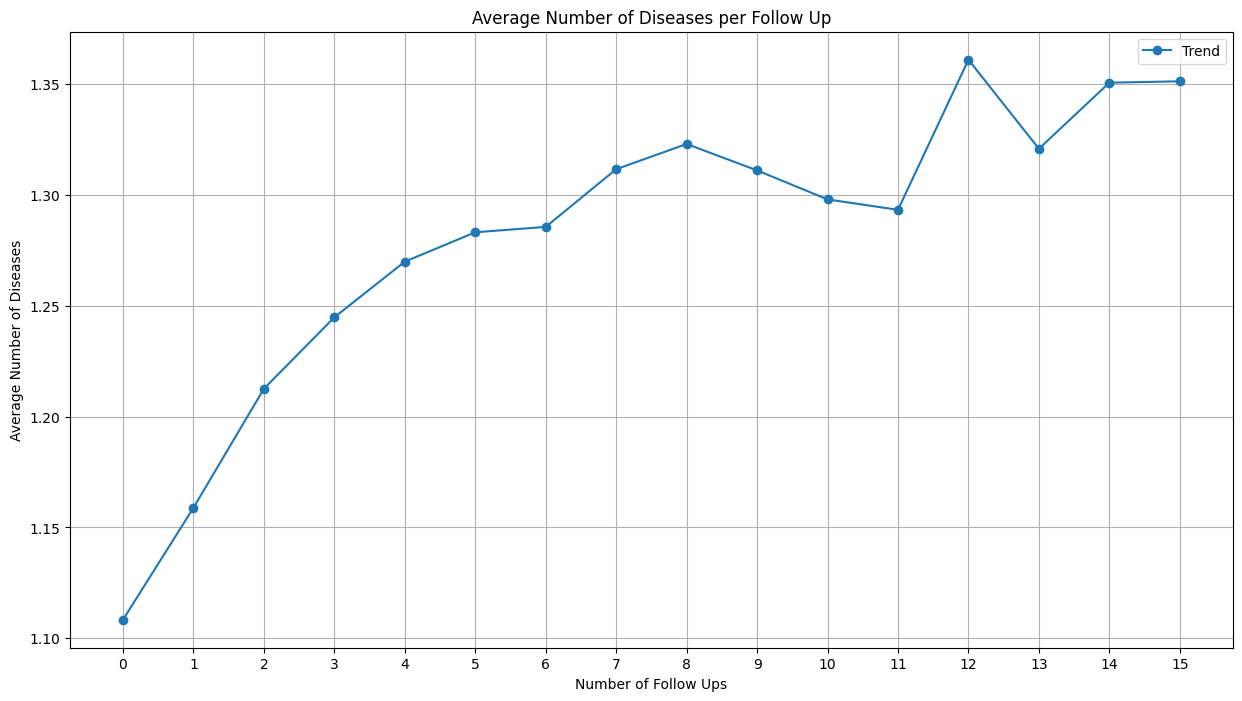

In [15]:
# Average number of diseases per follow up

# Group patients and follow-up number
img_level = train_val_labels.groupby(["patient_id","follow_up_number"]).sum()[labels]

# Add disease_count column for the total number of diagnosis per follow-up per patient
img_level["disease_count"] = img_level.sum(axis=1)

# Find the average number of diseases per follow up
avg_disease = img_level.groupby("follow_up_number")["disease_count"].mean()
print(avg_disease)

# Line plot showing disease trends 
plt.figure(figsize=(15,8))
plt.plot(avg_disease, marker="o", label="Trend")
plt.title("Average Number of Diseases per Follow Up")
plt.xlabel("Number of Follow Ups")
plt.xticks(range(0, train_val_labels["follow_up_number"].max()+1))
plt.ylabel("Average Number of Diseases")
plt.grid()
plt.legend()
plt.show()

As the number of follows per patient increases, so does the average number of diseases per those patients, suggesting a positive relationship

Average patient age: 50.19


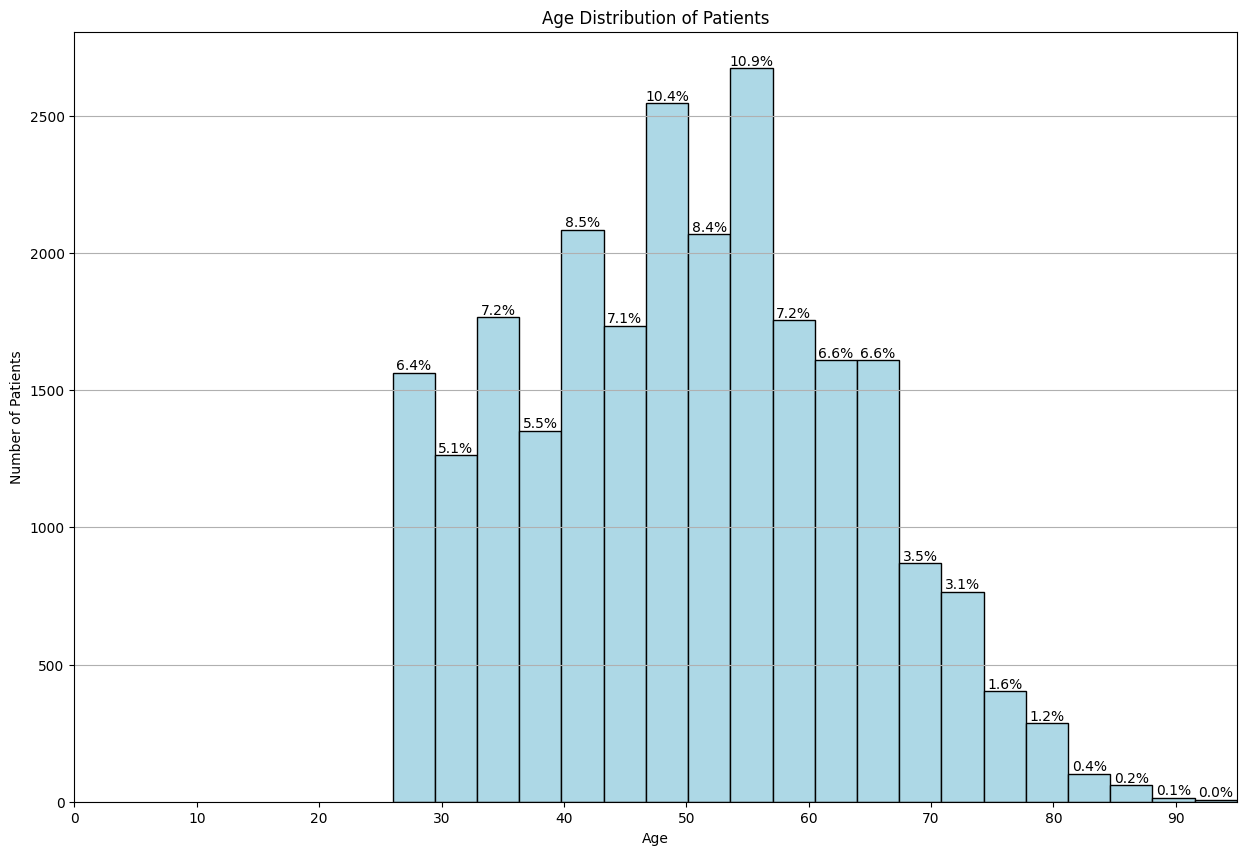

In [16]:
# Age distribution of patients

# extracted the age of each unique patient
patient_ages = train_val_labels.groupby("patient_id")["patient_age"].first()

# calculated the average patient age
print(f'Average patient age: {patient_ages.mean().round(2)}')

# plotted histogram 
plt.figure(figsize=(15,10))
counts, bins, patches = plt.hist(patient_ages, bins=20, color="lightblue",edgecolor="black")
plt.title("Age Distribution of Patients")
plt.xticks(range(0, patient_ages.max(), 10))
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.xlim(0, patient_ages.max())

total = counts.sum()
percentages = [f"{(c/total * 100):.1f}%" for c in counts]

plt.bar_label(patches, labels=percentages)
plt.grid(axis='y')
plt.show()

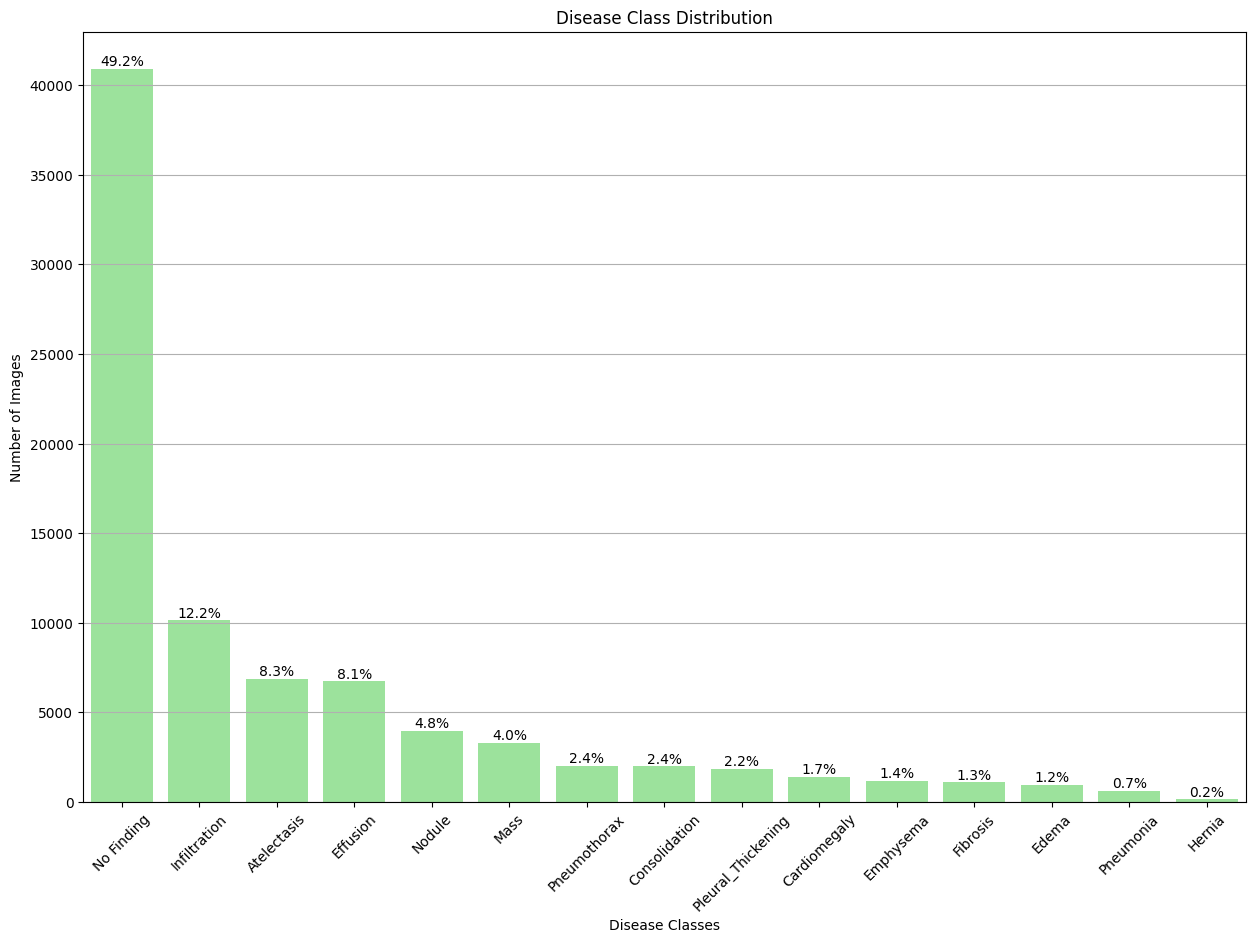

In [17]:
# Distribution of disease classes

label_counts = train_labels_y.sum().sort_values(ascending=False)
total = label_counts.sum()

plt.figure(figsize=(15,10))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, color="lightgreen")
plt.xticks(rotation=45)
plt.title("Disease Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

for i, count in enumerate(label_counts.values):
    percentage = count/total * 100
    ax.text(i, count + 5, f"{percentage:.1f}%", ha='center', va='bottom', fontsize=10)

plt.grid(axis='y')
plt.show()

The distribution of classes is dominated by class ("No Finding"). The gap between the top class the the next may have a large impact on model performance as models tend to bias the majority class while potentially not learning the classes with less labels such as the "Hernia" or "Pneumonia" class.

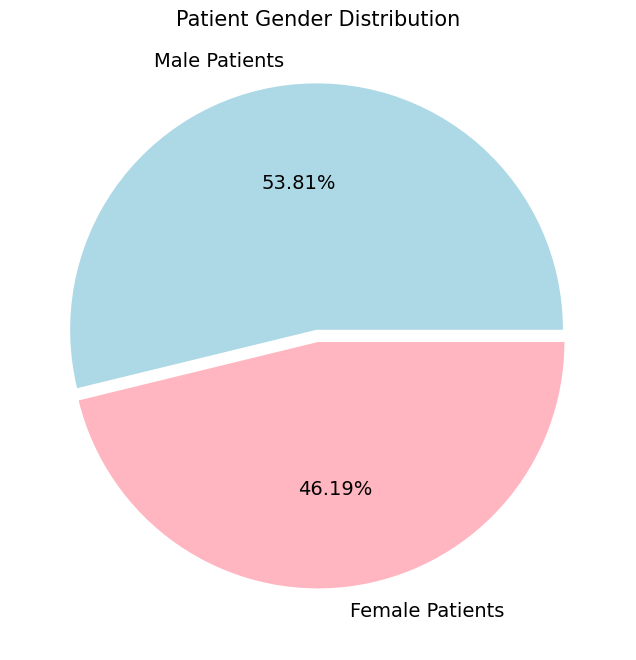

In [18]:
# Patient gender distribution

# extracted gender of each unique patient
patient_gender = train_val_labels.groupby("patient_id")["patient_gender"].first()
gender = patient_gender.value_counts()

# plot pie chart
plt.figure(figsize=(12,8))
plt.pie(gender.values, labels=["Male Patients", "Female Patients"], autopct="%.2f%%", explode=[0.05,0], colors=["lightblue", "lightpink"], textprops={"fontsize": 14})
plt.title("Patient Gender Distribution", fontsize=15)
plt.show()

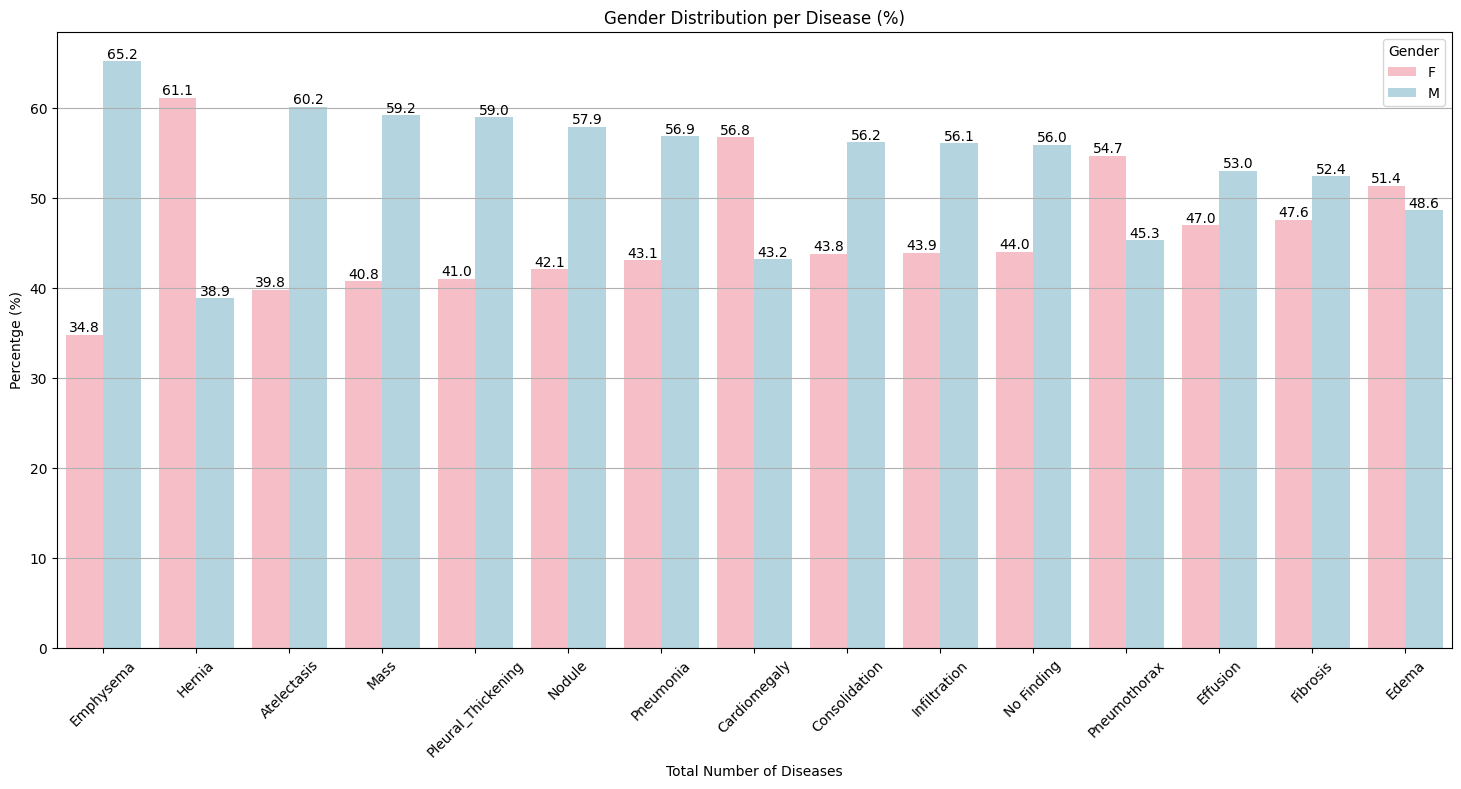

In [19]:
# Gender distribution per disease 

# Group disease by gender and compute percentages
diseases_grouped_by_gender = train_val_labels.groupby(["patient_gender"])[labels].sum()
disease_percentages = (diseases_grouped_by_gender.div(diseases_grouped_by_gender.sum(axis=0), axis=1) * 100).round(2)

# Reshape for seaborn
disease_percentages_sns = disease_percentages.reset_index().melt(id_vars="patient_gender", var_name="Diseases", value_name="Percentage").sort_values(by="Percentage", ascending=True)

# Plot grouped bar chart for gender distribution per disease
plt.figure(figsize=(18,8))

barplot = sns.barplot(data=disease_percentages_sns, x="Diseases", y="Percentage", hue="patient_gender", palette={"F": "lightpink", "M": "lightblue"})
plt.title("Gender Distribution per Disease (%)")
plt.xlabel("Total Number of Diseases")
plt.ylabel("Percentge (%)")
plt.xticks(rotation=45)

for container in barplot.containers:
    barplot.bar_label(container, fmt='%.1f')

plt.legend(title="Gender")
plt.grid(axis="y")
plt.show()

Based on the gender distribution per disease, males have a overall higher prevalence accross diseases, however several conditions such as Hernia, Cardiomegaly, Pneumothorax, and Edema are much more common in females despite males representing a larger percentage of the dataset than females (53.81% males to 46.19% femlaes). The fact that females still dominate these conditions despite there smaller representation in the sample accentuates the dominace of these female dominated diseases.

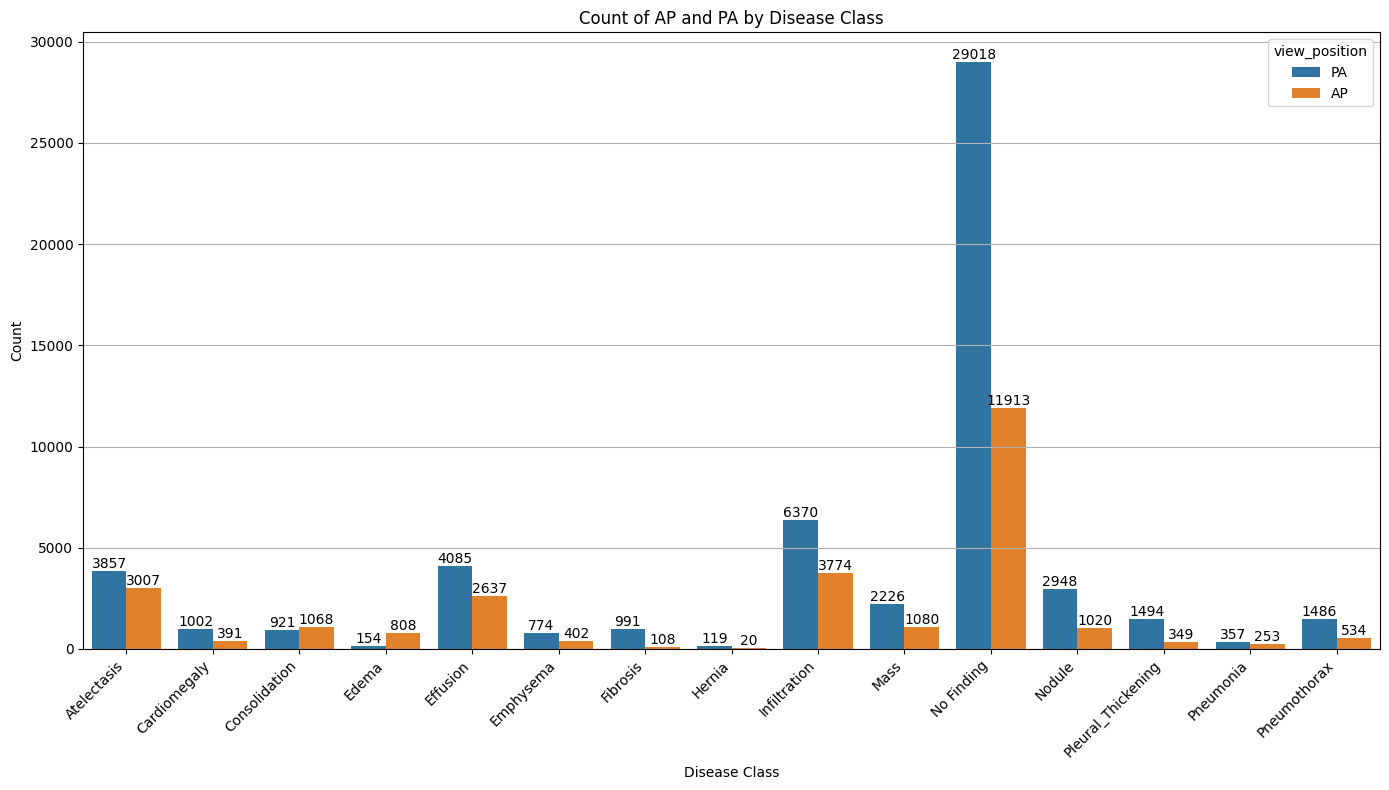

In [20]:
# Countplot comparing the distribution of label classes based on view position

train_val_labels_countplot = train_val_labels[labels + ["view_position"]]

df_melted = train_val_labels_countplot.melt(id_vars=["view_position"], value_vars=labels, var_name="Disease", value_name="present")
df_melted = df_melted[df_melted["present"]==1]

plt.figure(figsize=(14,8))
countplot = sns.countplot(x="Disease", data=df_melted, hue="view_position")

for container in countplot.containers:
    countplot.bar_label(container, fmt='%d')

plt.xticks(rotation=45, ha="right")
plt.title("Count of AP and PA by Disease Class")
plt.ylabel("Count")
plt.xlabel("Disease Class")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

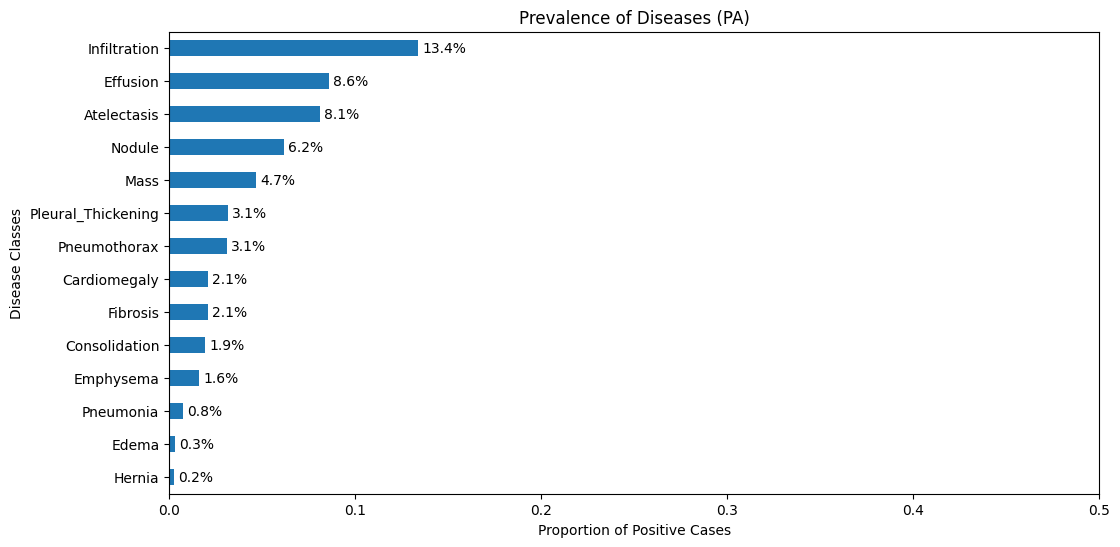

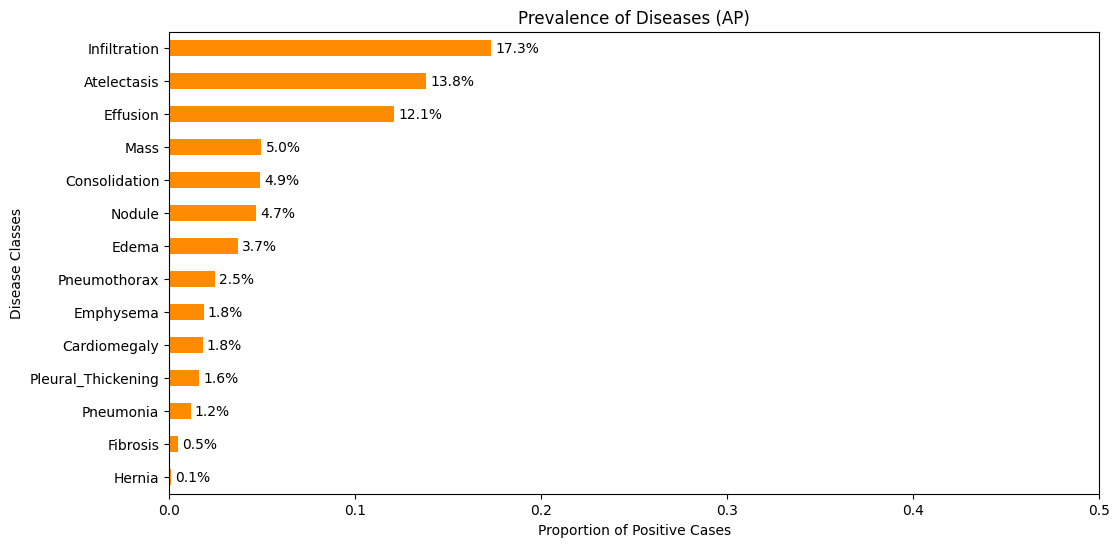

The average number of diseases per sample for x-rays taken in a PA view is 0.56
The average number of diseases per sample for x-rays taken in a AP view is 0.71
Samples taken in AP have an average of 0.15 more diseases per sample
AP samples have about 27.0% more diseases per sample on average to PA samples


In [21]:
# Horizontal bar plot of prevalence of disease based on view position

pa_train_val_labels = train_val_labels.loc[train_val_labels["view_position"] == "PA", labels].drop(columns=["No Finding"], axis=1)
ap_train_val_labels = train_val_labels.loc[train_val_labels["view_position"] == "AP", labels].drop(columns=["No Finding"], axis=1)

prevalence_pa = (pa_train_val_labels.sum()/pa_train_val_labels.shape[0]).round(4).sort_values(ascending=True)
prevalence_ap = (ap_train_val_labels.sum()/ap_train_val_labels.shape[0]).round(4).sort_values(ascending=True)

# PA view
plt.figure(figsize=(12,6))
ax = prevalence_pa.plot(kind="barh")
ax.bar_label(ax.containers[0], labels=[f"{p*100:.1f}%" for p in prevalence_pa.values], padding=3)
plt.title("Prevalence of Diseases (PA)")
plt.xlabel("Proportion of Positive Cases")
plt.ylabel("Disease Classes")
plt.xlim(0,0.5)
plt.show()

# AP view
plt.figure(figsize=(12,6))
ax = prevalence_ap.plot(kind="barh", color="darkorange")
ax.bar_label(ax.containers[0], labels=[f"{p*100:.1f}%" for p in prevalence_ap.values], padding=3)
plt.title("Prevalence of Diseases (AP)")
plt.xlabel("Proportion of Positive Cases")
plt.ylabel("Disease Classes")
plt.xlim(0,0.5)
plt.show()

# Summary
print(f"The average number of diseases per sample for x-rays taken in a PA view is {prevalence_pa.sum().round(2)}")
print(f"The average number of diseases per sample for x-rays taken in a AP view is {prevalence_ap.sum().round(2)}")
print(f"Samples taken in AP have an average of {(prevalence_ap.sum() - prevalence_pa.sum()).round(2)} more diseases per sample")
print(f"AP samples have about {((prevalence_ap.sum().round(2) - prevalence_pa.sum().round(2))/prevalence_pa.sum().round(2)).round(2)*100}% more diseases per sample on average to PA samples")

These prevelance charts compares the probability that a randomly selected sample has a given disease based on view position. Based on the charts above, patients with x-rays taken in AP view have roughly 4% higher probability of being diagnosed with infiltration and a 4-5% higher chance for atelectasis and effusion. The average number of disease per sample for AP and PA view are 0.71 and 0.56, meaning that on average, samples in AP view have an average of 0.15 more diseases or 27% more diseases per sample when compared to PA samples

## Correlation Analysis

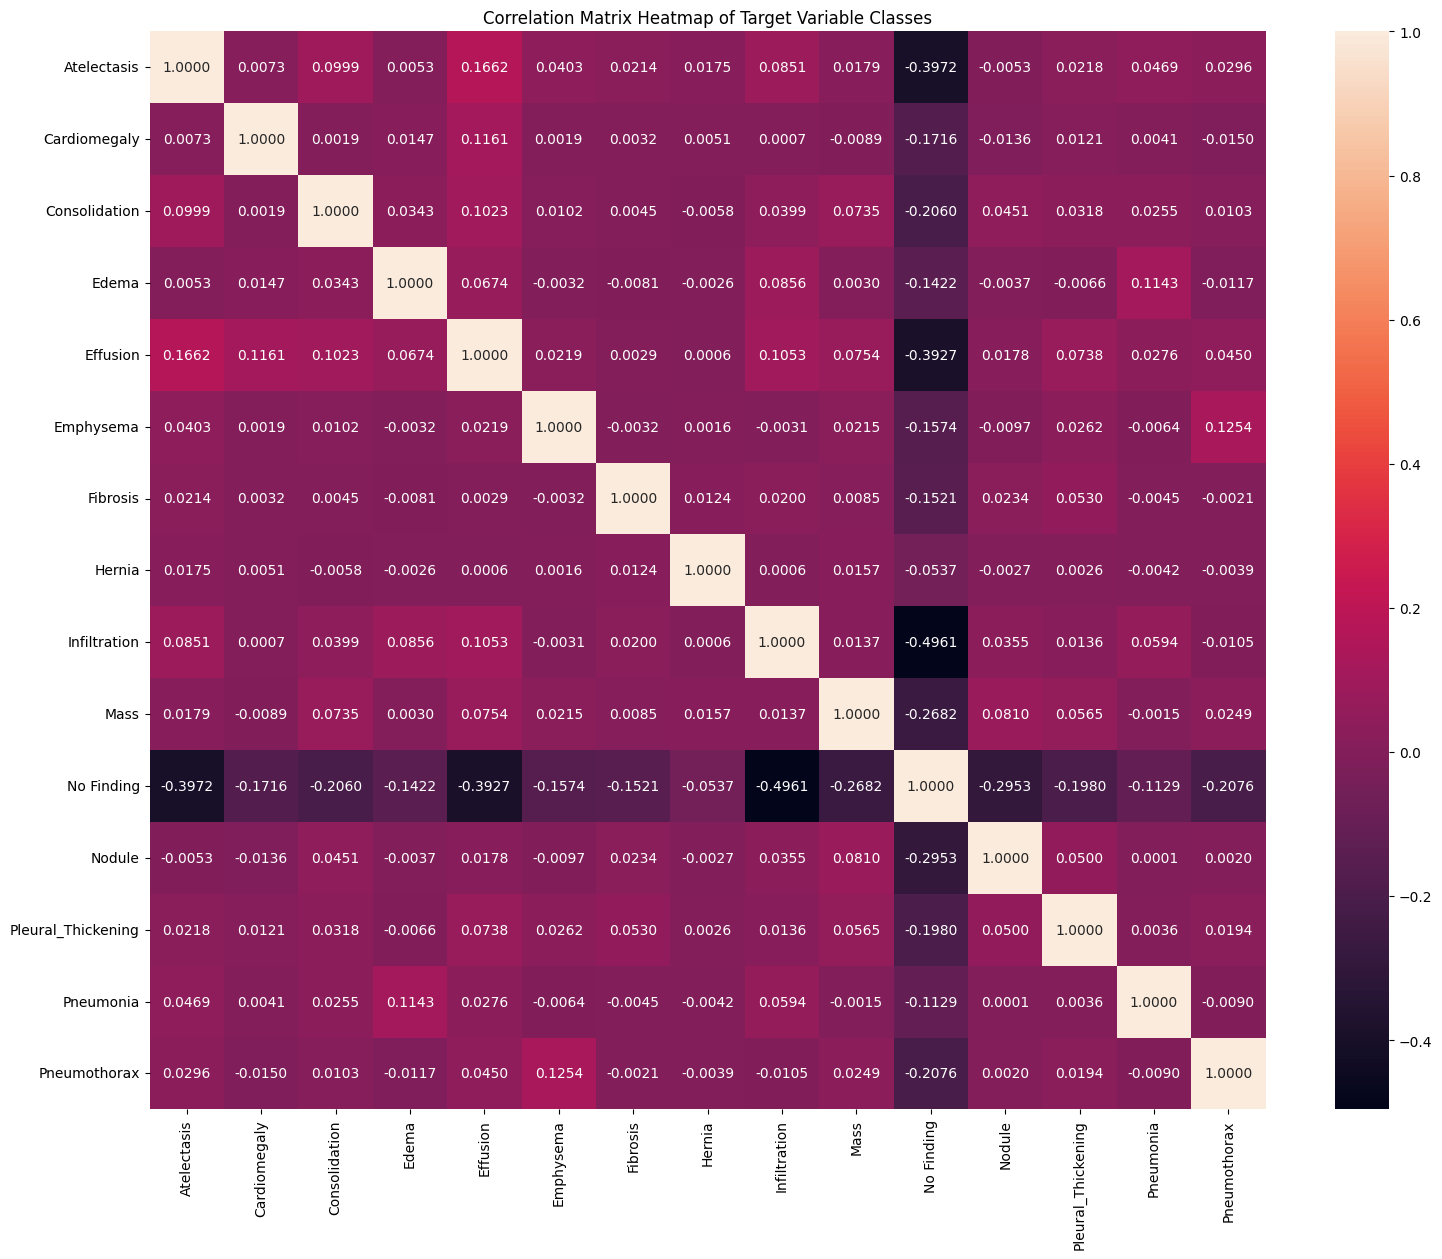

In [22]:
# Plot correlation matrix 

corr_matrix = train_labels_y.corr()

plt.figure(figsize=(18,14))
sns.heatmap(corr_matrix, annot=True, fmt=".4f")
plt.title("Correlation Matrix Heatmap of Target Variable Classes")
plt.show()

The correlation matrix reveals that most diseases have a weak positive or negative correlation to each other, signifying a weak linear relationship. The "No Finding" class as negative correlation with every disease and a moderate to strong negative correlation with the "Effusion" and "Infiltration" class, signifying an inverse relationship. 

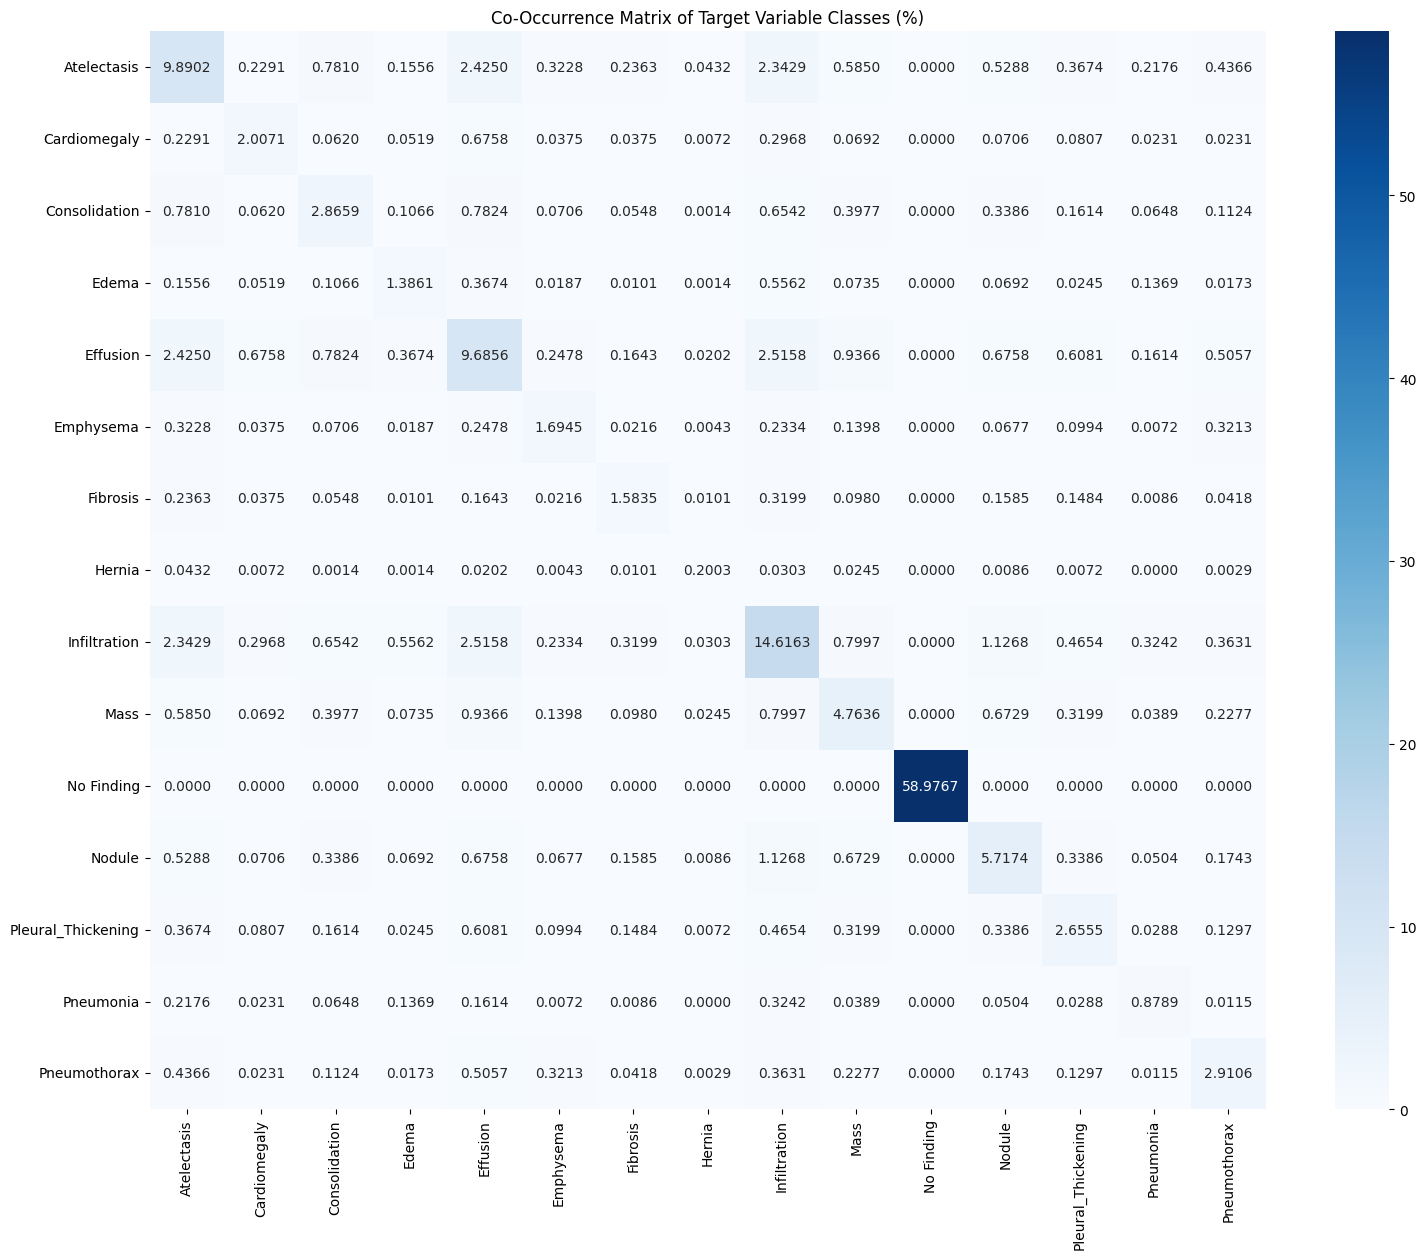

In [23]:
# Plot Co-occurence matrix

co_occurrence = train_labels_y.T.dot(train_labels_y)

plt.figure(figsize=(18,14))
sns.heatmap((co_occurrence/ train_labels_y.shape[0])*100, annot=True, cmap="Blues", fmt=".4f")
plt.title("Co-Occurrence Matrix of Target Variable Classes (%)")
plt.show()

The co-occurrence matrix reveals that the "Actelectasis", "Effusion", and "Infiltration" class often appear together, at around 2.4% of the dataset or roughly 2000 samples in the dataset. 

## Multi-Label Co-occurrence Frequency Table

The table below shows the top 15 most common label combinations in the training/validation set. This motivates the multi-label formulation — many images have multiple simultaneous conditions.

,Label Combination,Count,Percentage
0,No Finding,40931,58.98
1,Infiltration,5487,7.91
2,Atelectasis,2943,4.24
3,Effusion,2205,3.18
4,Nodule,1960,2.82
5,Mass,1435,2.07
6,Pneumothorax,985,1.42
7,Atelectasis | Infiltration,738,1.06
8,Pleural_Thickening,697,1.00
9,Atelectasis | Effusion,688,0.99


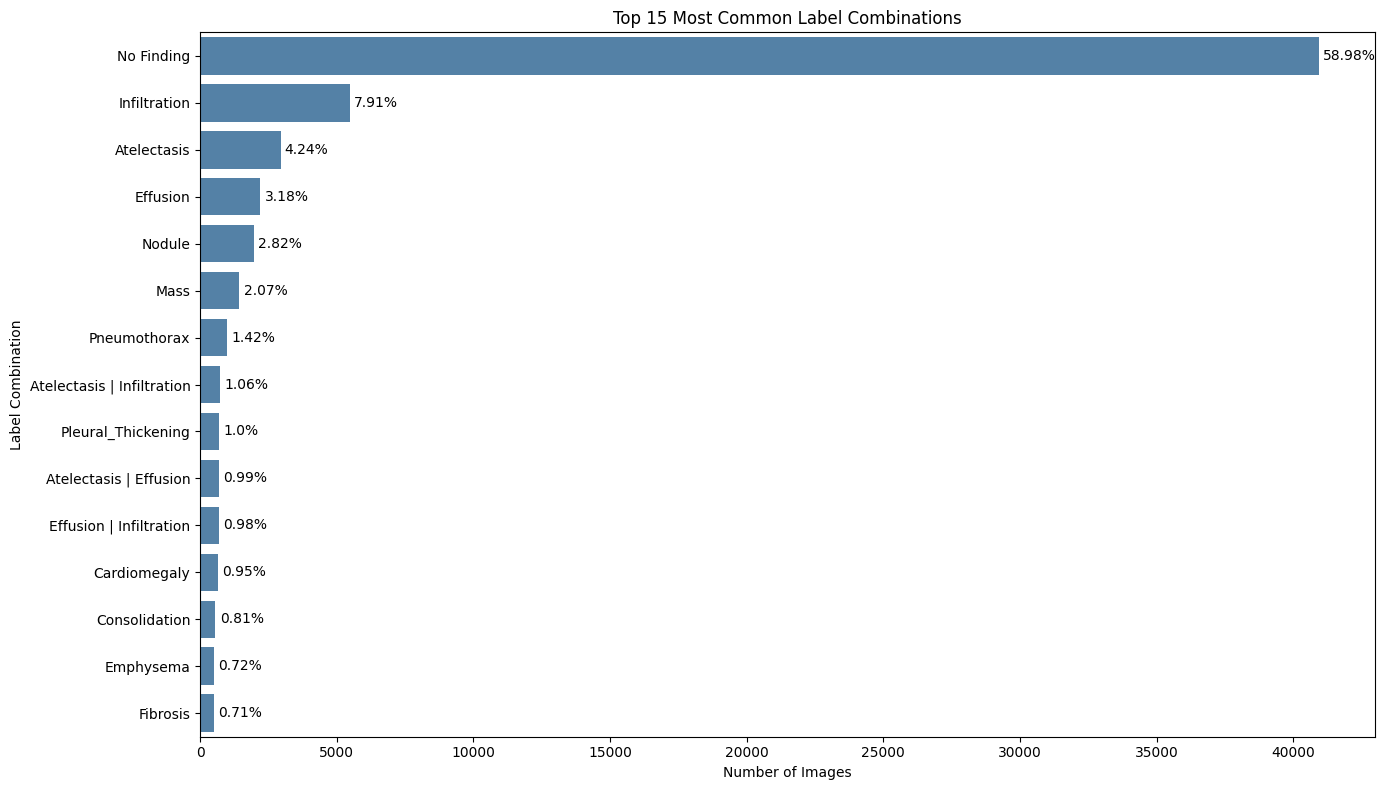


Total unique label combinations: 563
Images with multiple conditions: 10030 (14.5%)


In [25]:
# Top 15 most common label combinations
label_combinations = train_labels_y.apply(lambda row: " | ".join([labels[i] for i, v in enumerate(row) if v == 1]), axis=1)
combo_counts = label_combinations.value_counts().head(15)

combo_df = pd.DataFrame({
    "Label Combination": combo_counts.index,
    "Count": combo_counts.values,
    "Percentage": (combo_counts.values / len(train_labels_y) * 100).round(2)
})

display(combo_df)

# Visualize
plt.figure(figsize=(14, 8))
ax = sns.barplot(data=combo_df, x="Count", y="Label Combination", orient="h", color="steelblue")
ax.bar_label(ax.containers[0], labels=[f"{p}%" for p in combo_df["Percentage"].values], padding=3)
plt.title("Top 15 Most Common Label Combinations")
plt.xlabel("Number of Images")
plt.ylabel("Label Combination")
plt.tight_layout()
plt.show()

print(f"\nTotal unique label combinations: {label_combinations.nunique()}")
print(f"Images with multiple conditions: {(train_labels_y.sum(axis=1) > 1).sum()} ({(train_labels_y.sum(axis=1) > 1).mean()*100:.1f}%)")

In [26]:
# Export data

train_val_labels.to_csv('../data/labels/train_val_labels.csv')
test_labels.to_csv('../data/labels/test_labels.csv')